# Notebook Fusion — Pipeline complet

Ce notebook regroupe l'ensemble du travail :
1. **Transformation des donnees** (KNN imputation, nettoyage outliers, normalisation Z-Score)
2. **Random Forest Classifier**
3. **Perceptron Multi-Couches (MLP Classifier)**
4. **Etude comparative** (matrices de confusion, ROC, precision/recall/F1, temps d'execution)

---
# PARTIE 1 — Pipeline de transformation des donnees

**Source** : `housing.csv` (donnees brutes) → **Sortie** : `amputed_normalized_housing_data.csv`

| Etape | Operation | Detail |
|-------|-----------|--------|
| 1 | Imputation KNN | `total_bedrooms` — 207 NaN combles par $k=5$ voisins ponderes par distance |
| 2 | Encodage ordinal | `ocean_proximity` → 0–4 |
| 3 | Nettoyage outliers | Suppression prix plafonnes (500 001$) + IQR sur features numeriques |
| 4 | Normalisation Z-Score | $z = \frac{x - \mu}{\sigma}$ sur toutes les features sauf `median_house_value` (cible) |

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

housing = pd.read_csv('./datasets/housing.csv')
print(f"Shape : {housing.shape}")
print(f"Valeurs manquantes : total_bedrooms → {housing['total_bedrooms'].isnull().sum()}")

Shape : (20640, 10)
Valeurs manquantes : total_bedrooms → 207


## 1. Imputation KNN ($k=5$, ponderation par distance)

$$\hat{x}_i = \frac{\sum_{j \in \mathcal{N}_k(i)} w_j \cdot x_j}{\sum_{j \in \mathcal{N}_k(i)} w_j}, \quad w_j = \frac{1}{d(i,j)}$$

On standardise temporairement avant KNN pour que la distance euclidienne soit coherente entre colonnes.

In [2]:
# Encodage temporaire de ocean_proximity pour KNN (numérique requis)
ocean_mapping = {'<1H OCEAN': 0, 'INLAND': 1, 'ISLAND': 2, 'NEAR BAY': 3, 'NEAR OCEAN': 4}
housing['ocean_proximity'] = housing['ocean_proximity'].map(ocean_mapping)

# Standardisation temporaire → KNN → dé-standardisation
num_cols = housing.columns.tolist()
means, stds = housing[num_cols].mean(), housing[num_cols].std()
X_scaled = (housing[num_cols] - means) / stds

imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_scaled) * stds.values + means.values,
    columns=num_cols, index=housing.index
)
housing['total_bedrooms'] = X_imputed['total_bedrooms'].round(0)

print(f"Valeurs manquantes après imputation : {housing.isnull().sum().sum()}")

Valeurs manquantes après imputation : 0


## 2. Nettoyage des outliers

**2a.** Suppression des prix plafonnes (`median_house_value == 500001`) — donnees censurees, pas des prix reels.

**2b.** Suppression des outliers IQR sur les features numeriques (sauf `ocean_proximity` et `median_house_value`) :

$$\text{outlier si } x < Q_1 - 1.5 \times IQR \text{ ou } x > Q_3 + 1.5 \times IQR$$

In [3]:
n_before = len(housing)

# 2a. Suppression des prix plafonnés
capped = (housing['median_house_value'] == 500001).sum()
housing = housing[housing['median_house_value'] != 500001]
print(f"Prix plafonnés supprimés : {capped}")

# 2b. Suppression des outliers IQR sur les features numériques
iqr_cols = [c for c in housing.columns if c not in ('ocean_proximity', 'median_house_value')]
mask = pd.Series(True, index=housing.index)

for col in iqr_cols:
    q1 = housing[col].quantile(0.25)
    q3 = housing[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    col_mask = (housing[col] >= lower) & (housing[col] <= upper)
    n_out = (~col_mask).sum()
    if n_out > 0:
        print(f"  {col:>20s} : {n_out} outliers (bornes [{lower:.1f}, {upper:.1f}])")
    mask &= col_mask

housing = housing[mask].reset_index(drop=True)
n_after = len(housing)
print(f"\nLignes supprimées : {n_before - n_after} ({(n_before - n_after)/n_before*100:.1f}%)")
print(f"Lignes restantes  : {n_after}")

Prix plafonnés supprimés : 965
           total_rooms : 1251 outliers (bornes [-1085.0, 5643.0])
        total_bedrooms : 1227 outliers (bornes [-229.5, 1174.5])
            population : 1126 outliers (bornes [-629.0, 3171.0])
            households : 1165 outliers (bornes [-204.0, 1092.0])
         median_income : 364 outliers (bornes [-0.6, 7.7])

Lignes supprimées : 3039 (14.7%)
Lignes restantes  : 17601


## 3. Normalisation Z-Score (features uniquement)

$$z = \frac{x - \mu}{\sigma}$$

`median_house_value` reste en valeur brute — c'est la cible du perceptron.

In [4]:
target = 'median_house_value'
feature_cols = [c for c in housing.columns if c != target]

scaler = StandardScaler()
housing[feature_cols] = scaler.fit_transform(housing[feature_cols])

print("Features (mean ≈ 0, std ≈ 1) :")
print(housing[feature_cols].describe().loc[['mean', 'std']].round(4))
print(f"\nmedian_house_value (non transformé) : mean={housing[target].mean():.0f}, std={housing[target].std():.0f}")

Features (mean ≈ 0, std ≈ 1) :
      longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
mean        0.0       0.0                -0.0          0.0             0.0   
std         1.0       1.0                 1.0          1.0             1.0   

      population  households  median_income  ocean_proximity  
mean         0.0        -0.0           -0.0              0.0  
std          1.0         1.0            1.0              1.0  

median_house_value (non transformé) : mean=187322, std=94874


## 4. Export

In [5]:
output_path = './datasets/amputed_normalized_housing_data.csv'
housing.to_csv(output_path, index=False)
print(f"Exporté : {output_path} — {housing.shape[0]} lignes, {housing.shape[1]} colonnes")
housing.head()

Exporté : ./datasets/amputed_normalized_housing_data.csv — 17601 lignes, 10 colonnes


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.315977,0.995320,1.83728,-0.622220,-1.156299,-1.161352,-1.168233,2.620165,352100.0,1.300935
1,-1.320967,0.995320,1.83728,-0.799883,-0.953182,-1.058970,-0.964205,1.477758,341300.0,1.300935
2,-1.320967,0.995320,1.83728,-0.474934,-0.750065,-1.047410,-0.769893,0.206130,342200.0,1.300935
3,-1.320967,0.995320,1.83728,-1.126674,-1.052484,-1.298413,-1.090508,0.341013,269700.0,1.300935
4,-1.320967,0.990705,1.83728,0.360912,0.193300,-0.173855,0.468851,0.073723,299200.0,1.300935


---
# Preparation pour la classification

On cree une variable cible binaire `expensive` :
- **1** si `median_house_value` > mediane
- **0** sinon

Les donnees transformees (PARTIE 1) sont reutilisees directement.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve
)

df = pd.read_csv('./datasets/amputed_normalized_housing_data.csv')

# Variable cible binaire
median_price = df['median_house_value'].median()
df['expensive'] = (df['median_house_value'] > median_price).astype(int)

print(f"Shape : {df.shape}")
print(f"\nDistribution de expensive :\n{df['expensive'].value_counts()}")
print(f"\nSeuil (mediane) : {median_price:.0f}")
df.head()

Shape : (17601, 11)

Distribution de expensive :
expensive
0    8808
1    8793
Name: count, dtype: int64

Seuil (mediane) : 169800


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,expensive
0,-1.315977,0.995320,1.83728,-0.622220,-1.156299,-1.161352,-1.168233,2.620165,352100.0,1.300935,1
1,-1.320967,0.995320,1.83728,-0.799883,-0.953182,-1.058970,-0.964205,1.477758,341300.0,1.300935,1
2,-1.320967,0.995320,1.83728,-0.474934,-0.750065,-1.047410,-0.769893,0.206130,342200.0,1.300935,1
3,-1.320967,0.995320,1.83728,-1.126674,-1.052484,-1.298413,-1.090508,0.341013,269700.0,1.300935,1
4,-1.320967,0.990705,1.83728,0.360912,0.193300,-0.173855,0.468851,0.073723,299200.0,1.300935,1


## Analyse de colinearite

On identifie les paires de features avec $|r| > 0.8$ et on supprime la moins correlee avec la cible.

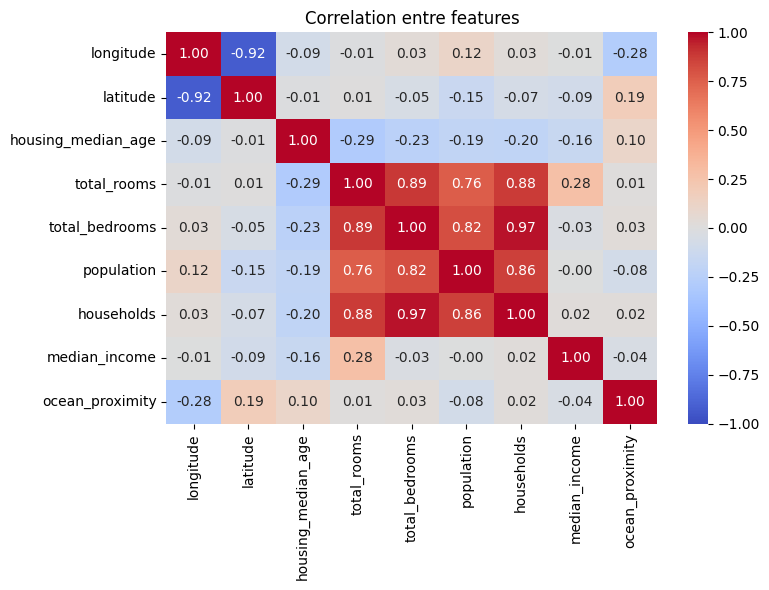

  longitude <-> latitude : r = -0.923
  total_rooms <-> total_bedrooms : r = 0.888
  total_rooms <-> households : r = 0.880
  total_bedrooms <-> population : r = 0.820
  total_bedrooms <-> households : r = 0.971
  population <-> households : r = 0.860


In [7]:
target = 'expensive'
features = [c for c in df.columns if c not in (target, 'median_house_value')]

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation entre features')
plt.tight_layout()
plt.show()

# Paires fortement correlees
threshold = 0.8
pairs = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        if abs(corr.iloc[i, j]) > threshold:
            pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))
            print(f"  {corr.index[i]} <-> {corr.columns[j]} : r = {corr.iloc[i, j]:.3f}")

if not pairs:
    print("Aucune paire avec |r| > 0.8")

In [8]:
# Suppression des features redondantes
target_corr = df[features].corrwith(df[target]).abs()

to_drop = set()
for a, b, r in pairs:
    drop = a if target_corr[a] < target_corr[b] else b
    to_drop.add(drop)
    print(f"  {a} (|r_target|={target_corr[a]:.3f}) vs {b} (|r_target|={target_corr[b]:.3f}) -> drop {drop}")

features_clean = [f for f in features if f not in to_drop]
print(f"\nFeatures conservees ({len(features_clean)}) : {features_clean}")
print(f"Features supprimees ({len(to_drop)}) : {to_drop}")

  longitude (|r_target|=0.020) vs latitude (|r_target|=0.163) -> drop longitude
  total_rooms (|r_target|=0.162) vs total_bedrooms (|r_target|=0.085) -> drop total_bedrooms
  total_rooms (|r_target|=0.162) vs households (|r_target|=0.114) -> drop households
  total_bedrooms (|r_target|=0.085) vs population (|r_target|=0.004) -> drop population
  total_bedrooms (|r_target|=0.085) vs households (|r_target|=0.114) -> drop total_bedrooms
  population (|r_target|=0.004) vs households (|r_target|=0.114) -> drop population

Features conservees (5) : ['latitude', 'housing_median_age', 'total_rooms', 'median_income', 'ocean_proximity']
Features supprimees (4) : {'population', 'households', 'longitude', 'total_bedrooms'}


## Train / Test split (70/30)

In [9]:
X = df[features_clean].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train : {X_train.shape[0]} echantillons ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} echantillons ({X_test.shape[0]/len(X)*100:.0f}%)")

Train : 12320 echantillons (70%)
Test  : 5281 echantillons (30%)


---
# PARTIE 2 — Random Forest Classifier

**Modele** : Ensemble de $B$ arbres de decision entraines sur des sous-echantillons bootstrap.

$$\hat{y} = \text{mode}\big(T_1(x), T_2(x), \ldots, T_B(x)\big)$$

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

print(f"Nombre d'arbres       : {rf_model.n_estimators}")
print(f"Profondeur max        : {rf_model.max_depth or 'illimitee'}")
print(f"Features par split    : {rf_model.max_features}")
print(f"Nombre de features    : {rf_model.n_features_in_}")

Nombre d'arbres       : 100
Profondeur max        : illimitee
Features par split    : sqrt
Nombre de features    : 5


### Importance des features

Importance des features :
  median_income             : 0.3727
  latitude                  : 0.2187
  ocean_proximity           : 0.1600
  total_rooms               : 0.1392
  housing_median_age        : 0.1093


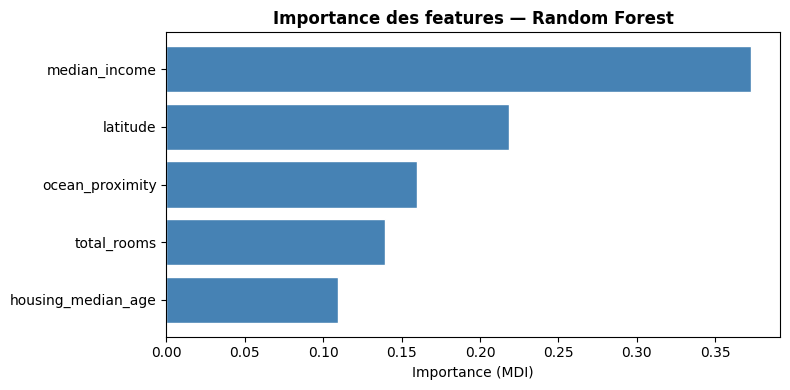

In [11]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Importance des features :")
for i in indices:
    print(f"  {features_clean[i]:25s} : {importances[i]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([features_clean[i] for i in indices[::-1]], importances[indices[::-1]], color='steelblue', edgecolor='white')
ax.set_xlabel('Importance (MDI)')
ax.set_title('Importance des features — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

### Visualisation d'un arbre individuel

Arbre n°0 de la foret, limite a une profondeur de 3 pour la lisibilite.

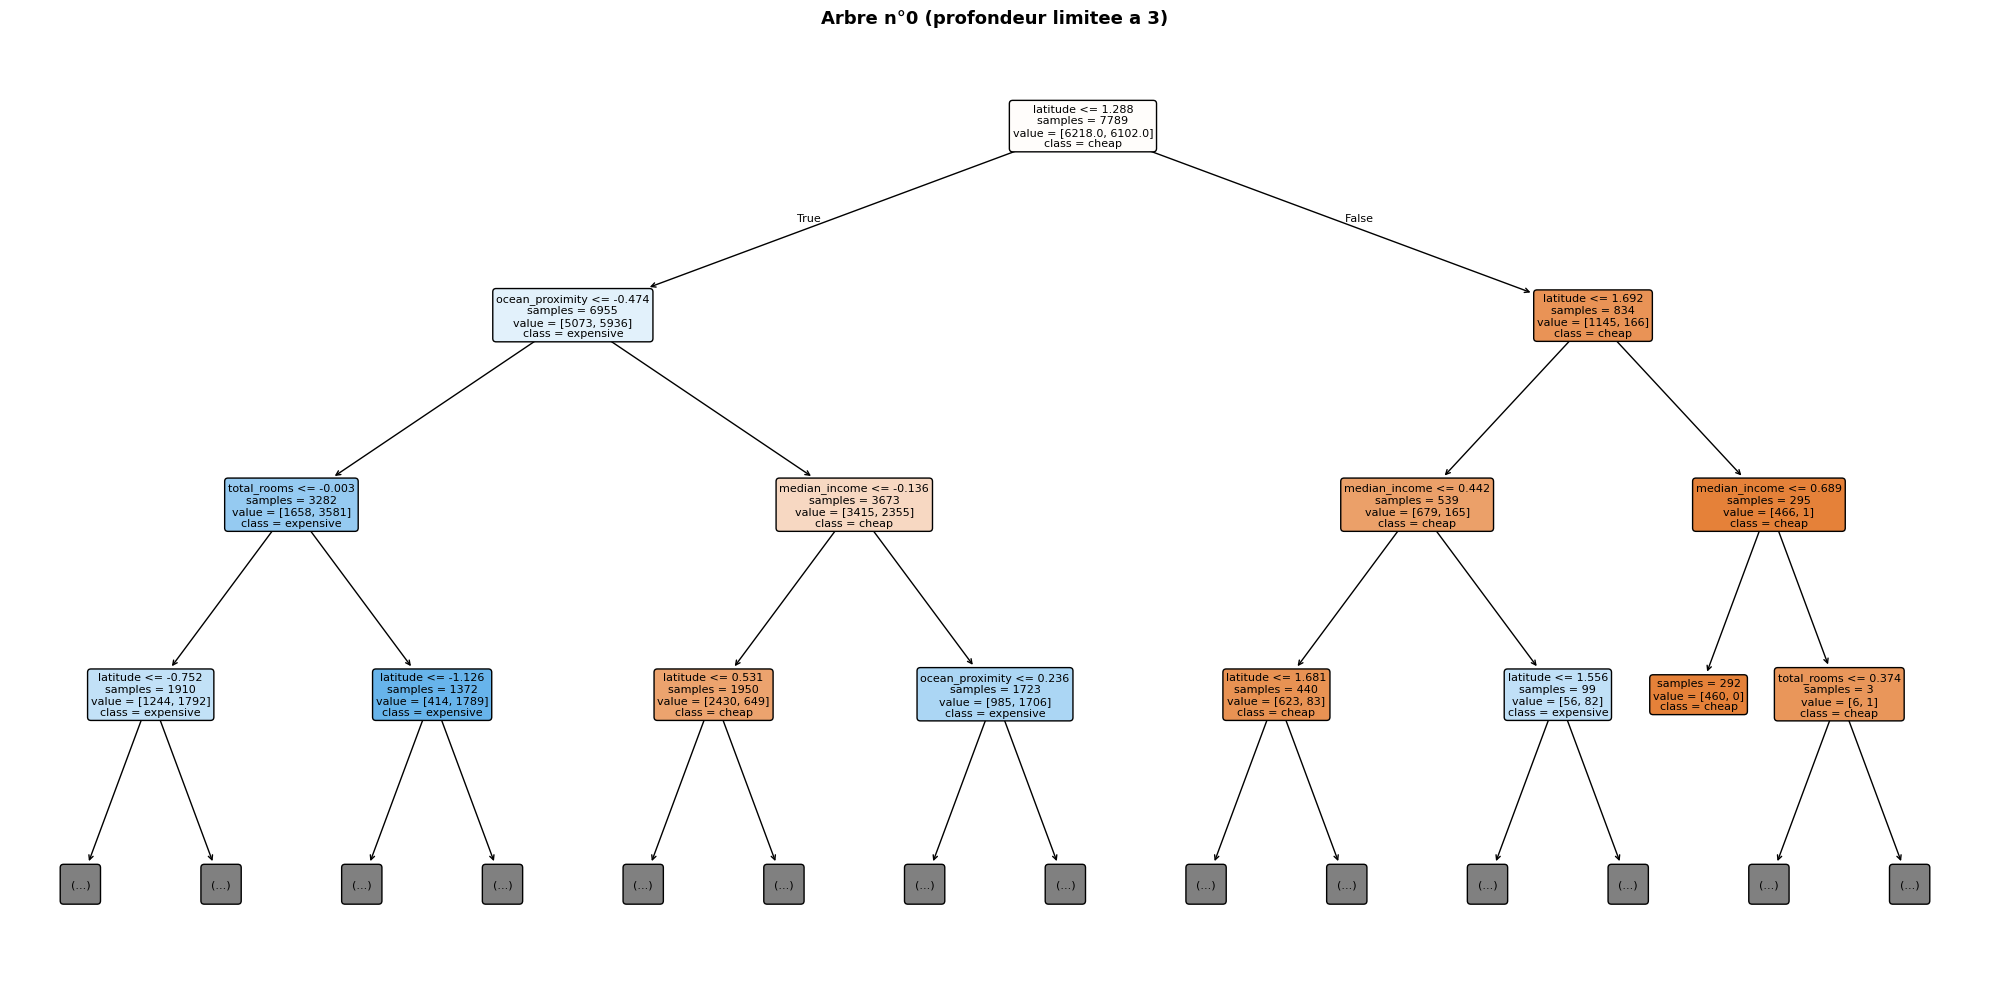

In [12]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[0],
    max_depth=3,
    feature_names=features_clean,
    class_names=['cheap', 'expensive'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=False,
)
ax.set_title('Arbre n°0 (profondeur limitee a 3)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Evaluation du Random Forest

In [13]:
y_pred_rf = rf_model.predict(X_test)

print("Matrice de Confusion (Random Forest) :")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_rf, target_names=['cheap', 'expensive']))

Matrice de Confusion (Random Forest) :
[[2213  417]
 [ 393 2258]]

Rapport de Classification :
              precision    recall  f1-score   support

       cheap       0.85      0.84      0.85      2630
   expensive       0.84      0.85      0.85      2651

    accuracy                           0.85      5281
   macro avg       0.85      0.85      0.85      5281
weighted avg       0.85      0.85      0.85      5281



---
# PARTIE 3 — Perceptron Multi-Couches (MLP)

**Modele** : Multi-Layer Perceptron (classification)

$$h^{(l)} = \text{ReLU}(W^{(l)} h^{(l-1)} + b^{(l)})$$
$$\hat{y} = \sigma(W^{(L)} h^{(L-1)} + b^{(L)})$$

Architecture : **features → 64 → 32 → 2** (2 couches cachees, activation ReLU, optimiseur Adam)

In [14]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
)

mlp_model.fit(X_train, y_train)

print(f"Couches cachees      : {mlp_model.hidden_layer_sizes}")
print(f"Activation           : {mlp_model.activation}")
print(f"Iterations effectuees : {mlp_model.n_iter_}")
print(f"Loss finale          : {mlp_model.loss_:.4f}")

Couches cachees      : (64, 32)
Activation           : relu
Iterations effectuees : 190
Loss finale          : 0.3491


### Courbe de convergence

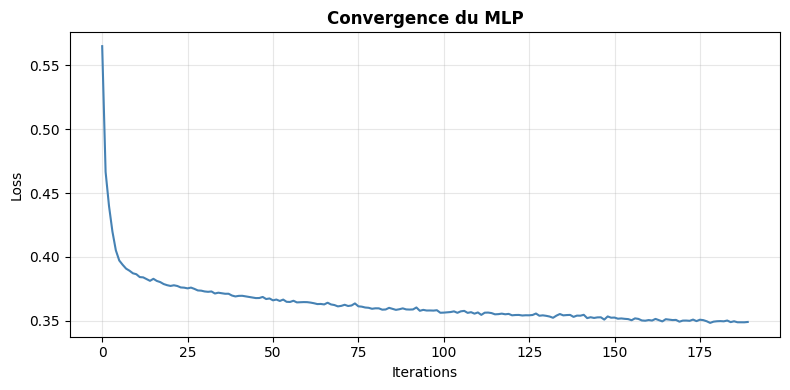

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, color='steelblue')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Convergence du MLP', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Architecture du MLP

Visualisation du reseau **features → 64 → 32 → 2**.

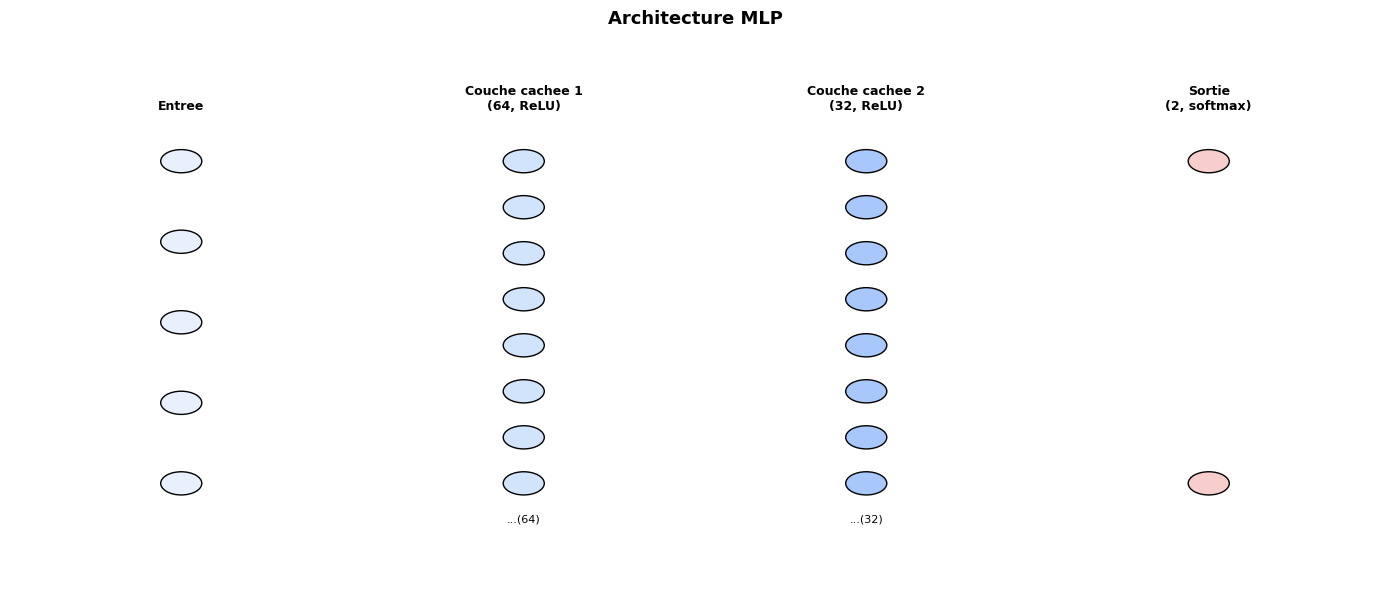

In [16]:
import matplotlib.patches as mpatches

layer_sizes = [len(features_clean), 64, 32, 2]
layer_labels = ['Entree', 'Couche cachee 1\n(64, ReLU)', 'Couche cachee 2\n(32, ReLU)', 'Sortie\n(2, softmax)']
colors = ['#e8f0fe', '#d2e3fc', '#a8c7fa', '#f8cecc']

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

x_positions = [1, 4, 7, 10]
max_draw = 8

for k, (x, size, label, color) in enumerate(zip(x_positions, layer_sizes, layer_labels, colors)):
    n_draw = min(size, max_draw)
    y_positions = np.linspace(0, 5, n_draw)
    for yp in y_positions:
        circle = plt.Circle((x, yp), 0.18, color=color, ec='black', lw=1)
        ax.add_patch(circle)
    if size > max_draw:
        ax.text(x, -0.6, f'...({size})', ha='center', fontsize=8)
    ax.text(x, 5.8, label, ha='center', fontweight='bold', fontsize=9)

ax.set_xlim(-0.5, 11.5)
ax.set_ylim(-1.5, 7)
ax.set_title('Architecture MLP', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Evaluation du MLP

In [17]:
y_pred_mlp = mlp_model.predict(X_test)

print("Matrice de Confusion (MLP) :")
print(confusion_matrix(y_test, y_pred_mlp))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_mlp, target_names=['cheap', 'expensive']))

Matrice de Confusion (MLP) :
[[2139  491]
 [ 382 2269]]

Rapport de Classification :
              precision    recall  f1-score   support

       cheap       0.85      0.81      0.83      2630
   expensive       0.82      0.86      0.84      2651

    accuracy                           0.83      5281
   macro avg       0.84      0.83      0.83      5281
weighted avg       0.84      0.83      0.83      5281



---
# PARTIE 4 — Etude comparative

Comparaison statistique des deux modeles (Random Forest vs MLP) a l'aide des metriques de classification.

In [18]:
models = {
    'Random Forest': rf_model,
    'MLP': mlp_model,
}

predictions = {
    'Random Forest': y_pred_rf,
    'MLP': y_pred_mlp,
}

## 1. Matrices de confusion

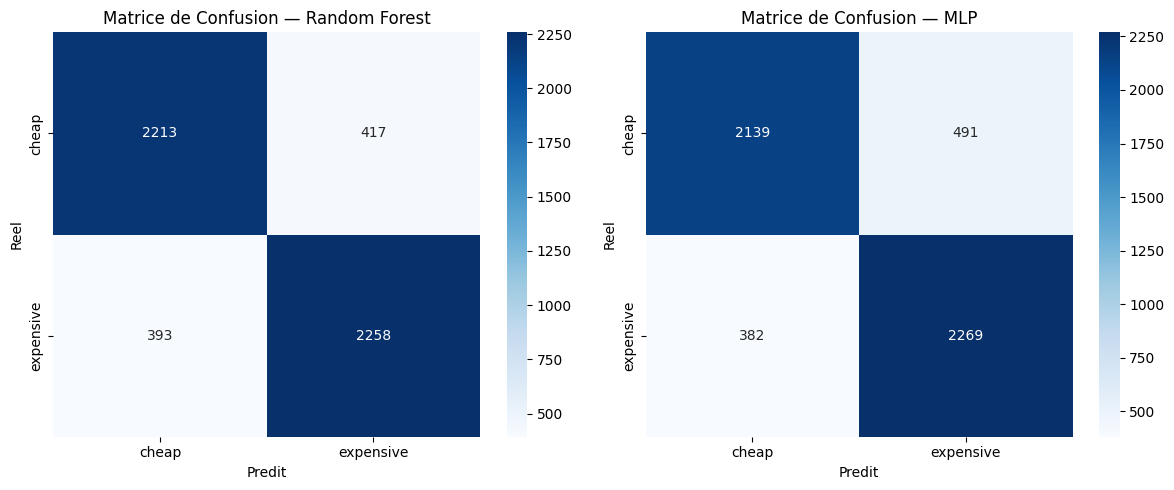

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['cheap', 'expensive'], yticklabels=['cheap', 'expensive'])
    ax.set_title(f'Matrice de Confusion — {name}')
    ax.set_ylabel('Reel')
    ax.set_xlabel('Predit')

plt.tight_layout()
plt.show()

## 2. Courbes Precision-Recall et ROC

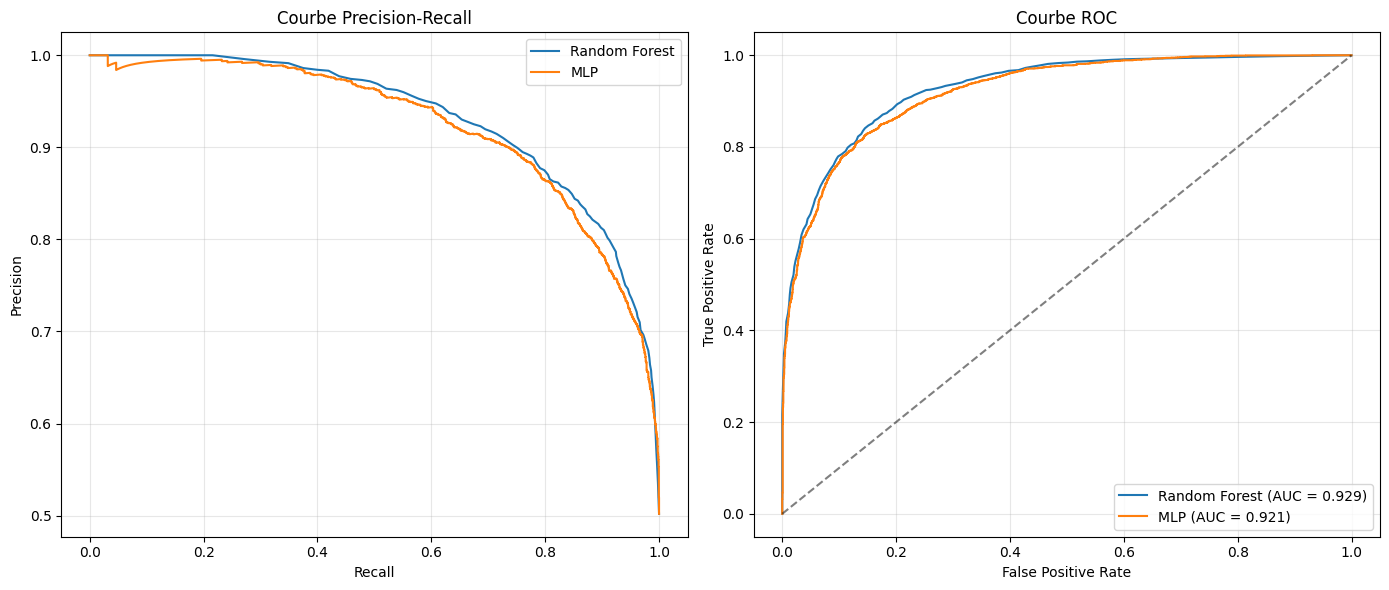

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ax1.plot(recall, precision, label=name)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax2.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Courbe Precision-Recall')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Courbe ROC')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Tableau comparatif des metriques

In [21]:
scores = []

for name, y_pred in predictions.items():
    y_proba = models[name].predict_proba(X_test)[:, 1]
    scores.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
    })

scores_df = pd.DataFrame(scores).set_index('Model')
print(scores_df.to_string())

               Precision    Recall  F1 Score       AUC
Model                                                 
Random Forest   0.844112  0.851754  0.847916  0.928947
MLP             0.822101  0.855903  0.838662  0.921341


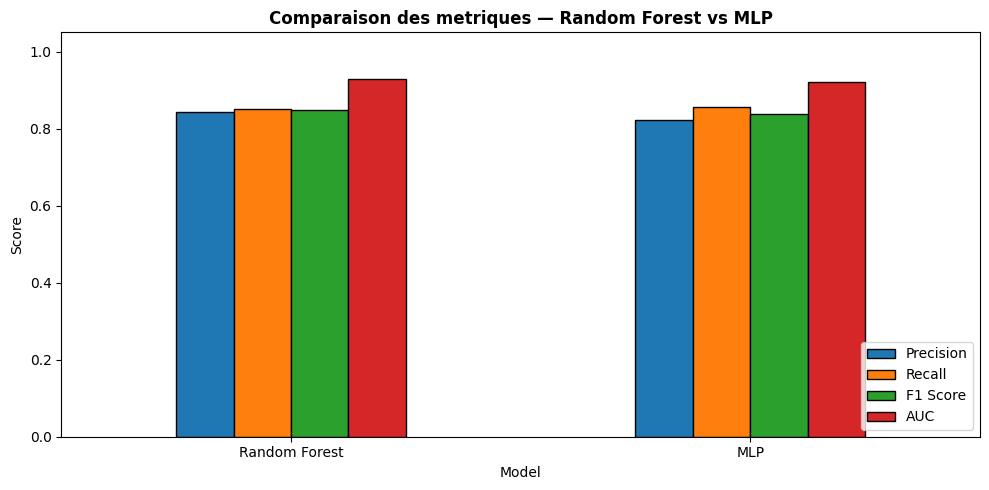

In [22]:
scores_df.plot(kind='bar', figsize=(10, 5), rot=0, edgecolor='black')
plt.title('Comparaison des metriques — Random Forest vs MLP', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Temps d'entrainement et de prediction

In [23]:
import time

timing = []

for name, model in models.items():
    # Re-entrainement pour mesurer le temps
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    model.predict(X_test)
    pred_time = time.time() - t0

    timing.append({'Model': name, 'Training (s)': round(train_time, 4), 'Prediction (s)': round(pred_time, 4)})

time_df = pd.DataFrame(timing).set_index('Model')
print(time_df.to_string())

               Training (s)  Prediction (s)
Model                                      
Random Forest        0.5767          0.0953
MLP                  6.5272          0.0437


## Interpretation des resultats

Les deux modeles sont compares sur la tache de classification binaire (`expensive` : prix > mediane).

- **Random Forest** : modele d'ensemble, robuste, interpretatble via l'importance des features.
- **MLP** : reseau de neurones, capture des relations non-lineaires complexes.

Les metriques (Precision, Recall, F1, AUC) et les temps d'execution permettent de choisir le modele le plus adapte au besoin.